# Валидация верификации диктора

Используем официальный список верификационных пар **VoxCeleb1-O** (`veri_test2.txt`, ~37 тыс. пар).

Источник: https://www.robots.ox.ac.uk/~vgg/data/voxceleb/meta/veri_test2.txt

Формат каждой строки: `label path1 path2`, где `label` = `1` (один и тот же диктор) или `0` (разные дикторы),
а `path1`/`path2` - относительные пути к `.wav` файлам внутри датасета VoxCeleb1 (`id/.../*.wav`).

**Важно:** Чтобы прогнать `verify()` из `app.py` на этих парах, нужно положить сами аудиофайлы VoxCeleb1 в `data/voxceleb1/` с сохранением исходной структуры путей, как указано в Readme.

In [1]:
import pandas as pd

PAIRS_PATH = "data/veri_test2.txt"
AUDIO_ROOT = "data/voxceleb1"  # сюда нужно положить аудио VoxCeleb1 при прогоне проверки

pairs = pd.read_csv(
    PAIRS_PATH,
    sep=" ",
    header=None,
    names=["label", "path1", "path2"],
)
print(f"Всего пар: {len(pairs)}")
pairs["label"].value_counts().rename({1: "SAME", 0: "DIFFERENT"})

Всего пар: 37611


label
DIFFERENT    18809
SAME         18802
Name: count, dtype: int64

In [2]:
pairs.head(10)

,label,path1,path2
0,1,id10270/x6uYqmx31kE/00001.wav,id10270/8jEAjG6SegY/00008.wav
1,0,id10270/x6uYqmx31kE/00001.wav,id10300/ize_eiCFEg0/00003.wav
2,1,id10270/x6uYqmx31kE/00001.wav,id10270/GWXujl-xAVM/00017.wav
3,0,id10270/x6uYqmx31kE/00001.wav,id10273/0OCW1HUxZyg/00001.wav
4,1,id10270/x6uYqmx31kE/00001.wav,id10270/8jEAjG6SegY/00022.wav
5,0,id10270/x6uYqmx31kE/00001.wav,id10284/Uzxv7Axh3Z8/00001.wav
6,1,id10270/x6uYqmx31kE/00001.wav,id10270/GWXujl-xAVM/00033.wav
7,0,id10270/x6uYqmx31kE/00001.wav,id10284/7yx9A0yzLYk/00029.wav
8,1,id10270/x6uYqmx31kE/00002.wav,id10270/5r0dWxy17C8/00026.wav
9,0,id10270/x6uYqmx31kE/00002.wav,id10285/m-uILToQ9ss/00009.wav


## Прогон верификации по парам

Код для вычисления `score`/`label` моделью из `app.py` по каждой паре и сравнения с эталонной
разметкой. Требует наличия аудиофайлов в `AUDIO_ROOT`.

In [3]:
import os
from tqdm.auto import tqdm
from app import verify

def full_path(rel_path):
    return os.path.join(AUDIO_ROOT, rel_path)

def run_verification(df, n=None, random_state=42):
    """Прогоняет verify() по строкам df и возвращает df с добавленными колонками
    predicted_label и score. n ограничивает число пар — берётся случайная подвыборка
    (df.sample), а не первые n строк: в veri_test2.txt пары сгруппированы по
    anchor-утерансу, поэтому head(n) при малых n даёт почти один и тот же id
    и смещённый баланс классов, а sample(n) — репрезентативный срез по id и меткам.
    random_state фиксирует подвыборку для воспроизводимости.
    Показывает progress bar (tqdm) по ходу выполнения."""
    subset = df.sample(n, random_state=random_state) if n else df
    results = []
    skipped = 0
    pbar = tqdm(subset.itertuples(index=False), total=len(subset), desc="Верификация пар")
    for row in pbar:
        p1, p2 = full_path(row.path1), full_path(row.path2)
        if not (os.path.exists(p1) and os.path.exists(p2)):
            skipped += 1  # пропускаем пары без скачанных аудиофайлов
            pbar.set_postfix(skipped=skipped)
            continue
        label, confidence, score = verify(p1, p2)
        results.append({
            "true_label": row.label,
            "predicted_label": 1 if label == "SAME" else 0,
            "score": score,
            "confidence": confidence,
        })
        pbar.set_postfix(skipped=skipped)
    return pd.DataFrame(results)

# Пример на небольшой подвыборке (уберите n, чтобы прогнать все ~37 тыс. пар)
results = run_verification(pairs, n=100)
results.head()

Верификация пар:   0%|          | 0/100 [00:00<?, ?it/s]

,true_label,predicted_label,score,confidence
0,0,0,-0.012854,0.024842
1,0,0,0.012383,0.032859
2,1,1,0.434269,0.807151
3,0,0,-0.036286,0.019125
4,0,0,0.144587,0.133118


## Метрики качества

Accuracy по порогу из `app.py`, а также EER (Equal Error Rate) по `score`, чтобы подобрать оптимальный `threshold`.

In [4]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score

def compute_eer(y_true, scores):
    """Возвращает (eer, threshold) — Equal Error Rate и порог, при котором FPR == FNR."""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer, thresholds[eer_idx]

def accuracy_at_threshold(y_true, scores, threshold):
    """Accuracy при заданном (уже выбранном) threshold — в отличие от compute_eer, порог
    не подбирается, а фиксирован. Используется, чтобы проверить обобщаемость уже
    откалиброванного порога на новом датасете (этапы 4, 5)."""
    preds = (np.asarray(scores) > threshold).astype(int)
    return accuracy_score(y_true, preds)

accuracy = accuracy_score(results["true_label"], results["predicted_label"])
eer, eer_threshold = compute_eer(results["true_label"], results["score"])
print(f"Accuracy: {accuracy:.4f}")
print(f"EER: {eer:.4f} при threshold={eer_threshold:.4f}")

Accuracy: 1.0000
EER: 0.0000 при threshold=0.3555


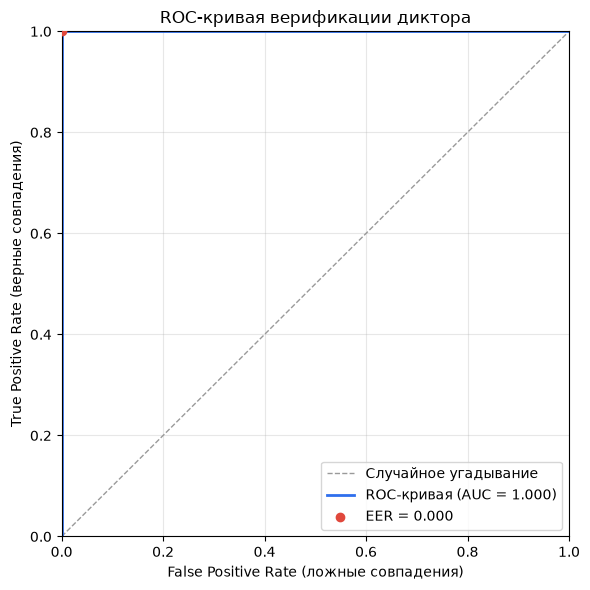

AUC: 1.0000 | EER: 0.0000 при threshold=0.3555


In [5]:
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, scores):
    """Строит ROC-кривую (FPR vs TPR) с отмеченными AUC и точкой EER."""
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)
    eer, eer_threshold = compute_eer(y_true, scores)

    fig, ax = plt.subplots(figsize=(6, 6))

    # диагональ — уровень случайного угадывания, ориентир для сравнения
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="#9a9a9a", label="Случайное угадывание")

    # сама ROC-кривая модели
    ax.plot(fpr, tpr, linewidth=2, color="#2f6fed", label=f"ROC-кривая (AUC = {auc:.3f})")

    # точка EER — где FPR == FNR (т.е. FPR == 1 - TPR)
    ax.scatter([eer], [1 - eer], color="#e0483c", zorder=5, label=f"EER = {eer:.3f}")

    ax.set_xlabel("False Positive Rate (ложные совпадения)")
    ax.set_ylabel("True Positive Rate (верные совпадения)")
    ax.set_title("ROC-кривая верификации диктора")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()

    return auc, eer, eer_threshold

auc, eer, eer_threshold = plot_roc_curve(results["true_label"], results["score"])
print(f"AUC: {auc:.4f} | EER: {eer:.4f} при threshold={eer_threshold:.4f}")

## Этап 1: Baseline проверка

Прежде чем добавлять любую деградацию (даунсемпл, шум и т.д.), нужно убедиться, что сам пайплайн
верификации (`app.py`) корректно работает на **чистых оригинальных** файлах VoxCeleb1 (16 кГц, без
изменений). Это обязательная проверка: если EER здесь окажется сильно выше опубликованного
бенчмарка, значит проблема в препроцессинге/коде, а не в датасете или условиях задания, и это нужно
поймать до того, как результаты смешаются с эффектом синтетического шума.

Шаги:
1. Взять случайную подвыборку пар из `veri_test2.txt` (300–500 пар достаточно для оценки EER).
2. Прогнать через `verify()` на оригинальных 16 кГц файлах, без даунсемпла и шума.
3. Посчитать EER и сравнить с опубликованным бенчмарком ECAPA-TDNN на VoxCeleb1-O (~0.8–1.0%).

In [6]:
# Опубликованный ориентир EER для ECAPA-TDNN (speechbrain/spkrec-ecapa-voxceleb) на VoxCeleb1-O.
# Источник: карточка модели speechbrain на HuggingFace / статья ECAPA-TDNN.
PUBLISHED_EER_RANGE = (0.008, 0.010)  # 0.8%–1.0%

BASELINE_SAMPLE_SIZE = 500  # 300-500 пар достаточно для стабильной оценки EER

# 1-2. Случайная подвыборка чистых пар + прогон через verify() на оригинальных 16 кГц файлах.
# random_state фиксирован — тот же сид, что и в run_verification по умолчанию (42),
# чтобы baseline и последующие уровни (2, 3...) сравнивались на одних и тех же парах.
baseline_results = run_verification(pairs, n=BASELINE_SAMPLE_SIZE, random_state=42)

# 3. EER на чистом baseline-срезе.
baseline_eer, baseline_threshold = compute_eer(
    baseline_results["true_label"], baseline_results["score"]
)
baseline_accuracy = accuracy_score(
    baseline_results["true_label"], baseline_results["predicted_label"]
)

print(f"Размер выборки: {len(baseline_results)} пар (из запрошенных {BASELINE_SAMPLE_SIZE})")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"EER: {baseline_eer:.4%} при threshold={baseline_threshold:.4f}")
print(
    f"Опубликованный бенчмарк ECAPA-TDNN на VoxCeleb1-O: "
    f"{PUBLISHED_EER_RANGE[0]:.1%}–{PUBLISHED_EER_RANGE[1]:.1%}"
)

# Вердикт: попадает ли наш EER в разумную окрестность опубликованного бенчмарка.
# Берём допуск с запасом (до 2x верхней границы), т.к. на подвыборке в 500 пар
# (вместо всех 37 тыс.) оценка EER статистически более шумная, чем на полном датасете.
sanity_ok = baseline_eer <= PUBLISHED_EER_RANGE[1] * 2
if sanity_ok:
    print("\n✅ Sanity check пройден: пайплайн работает корректно, можно переходить к Уровню 2.")
else:
    print(
        "\n⚠️ EER заметно выше бенчмарка — вероятен баг в препроцессинге "
        "(load_and_preprocess, ресемплинг, моно-конвертация) до симуляции шума."
    )

baseline_results.head()

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

Размер выборки: 500 пар (из запрошенных 500)
Accuracy: 0.9840
EER: 1.2007% при threshold=0.2914
Опубликованный бенчмарк ECAPA-TDNN на VoxCeleb1-O: 0.8%–1.0%

✅ Sanity check пройден: пайплайн работает корректно, можно переходить к Уровню 2.


,true_label,predicted_label,score,confidence
0,0,0,-0.012854,0.024842
1,0,0,0.012383,0.032859
2,1,1,0.434269,0.807151
3,0,0,-0.036286,0.019125
4,0,0,0.144587,0.133118


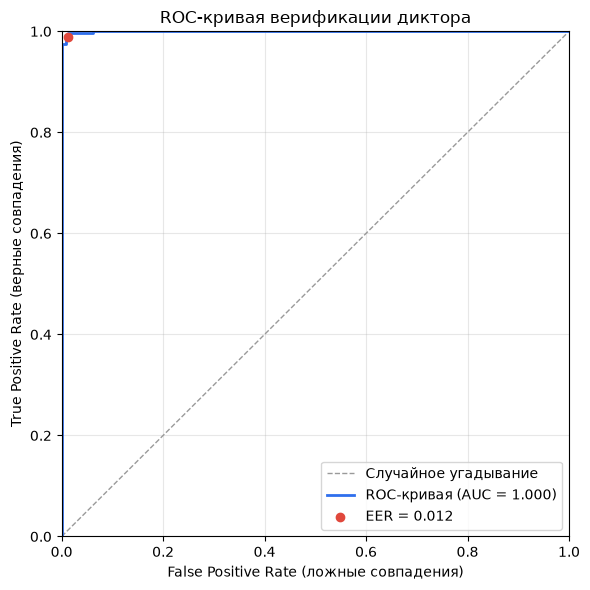

AUC (baseline, n=500): 0.9996


In [7]:
# ROC-кривая для baseline (Уровень 1) — отдельно от примера на n=100 выше.
baseline_auc, _, _ = plot_roc_curve(baseline_results["true_label"], baseline_results["score"])
print(f"AUC (baseline, n={len(baseline_results)}): {baseline_auc:.4f}")

## Этап 2: Симуляция целевых условий

Берём **те же самые пары** (тот же ground truth), что и в Уровне 1, но применяем к обоим файлам
каждой пары деградацию:

```
16kHz оригинал → downsample до 8kHz → + синтетический crackling
```

Апсемпл обратно до 16кГц отдельным шагом не нужен: `load_and_preprocess()` в `app.py` уже
ресемплирует любой вход до 16кГц перед подачей в модель, достаточно сохранить
деградированный файл в 8кГц, а дальнейшее приведение к формату модели произойдёт как обычно
внутри `verify()`. Степень деградации полностью определяется частотой дискретизации и
параметрами треска.

Разница между EER Уровня 1 (чистые данные) и EER Уровня 2 (деградированные) это честная
количественная оценка деградации от целевых условий.

**Используем три уровня интенсивности треска** (`light` / `medium` / `strong`), чтобы увидеть,
деградирует ли модель линейно с ростом шума или обрушивается резко после определённого порога.

In [8]:
import soundfile as sf
import torch
from app import load_and_preprocess

# Пресеты интенсивности треска: частота щелчков в секунду и их амплитуда.
# Каждый следующий уровень - примерно в 3-4 раза чаще и заметнее по громкости щелчков.
CRACKLE_PRESETS = {
    "light": {"clicks_per_sec": 2, "amplitude": 0.05},
    "medium": {"clicks_per_sec": 8, "amplitude": 0.15},
    "strong": {"clicks_per_sec": 20, "amplitude": 0.35},
}


def add_crackle_noise(wav, sr, intensity="light", rng=None):
    """Накладывает синтетический "треск" — случайные короткие затухающие импульсы,
    имитирующие помехи плохой аналоговой/телефонной линии.

    Параметры:
        wav (torch.Tensor): моно-сигнал формы (1, samples).
        sr (int): частота дискретизации сигнала в Гц.
        intensity (str): ключ из CRACKLE_PRESETS ("light" / "medium" / "strong").
        rng (np.random.Generator): генератор случайных чисел (для воспроизводимости).

    Возвращает:
        torch.Tensor той же формы (1, samples) с наложенным треском.
    """
    if intensity not in CRACKLE_PRESETS:
        raise ValueError(f"Неизвестный уровень интенсивности: {intensity!r}")
    if rng is None:
        rng = np.random.default_rng(42)

    cfg = CRACKLE_PRESETS[intensity]
    wav = wav.clone()  # не изменяем исходный тензор
    num_samples = wav.shape[-1]
    duration_sec = num_samples / sr

    # Сколько щелчков разместить на всей длине файла при заданной частоте (clicks_per_sec).
    num_clicks = max(1, int(cfg["clicks_per_sec"] * duration_sec))
    click_positions = rng.integers(0, num_samples, size=num_clicks)

    # Форма одного щелчка: короткий импульс (~2мс) с экспоненциальным затуханием.
    click_len = max(1, int(sr * 0.002))
    decay_curve = np.exp(-np.arange(click_len) / (click_len / 5))

    for pos in click_positions:
        polarity = rng.choice([-1.0, 1.0])  # щелчок может быть "вверх" или "вниз"
        peak = cfg["amplitude"] * rng.uniform(0.5, 1.0) * polarity
        end = min(pos + click_len, num_samples)
        seg_len = end - pos
        wav[0, pos:end] += torch.from_numpy((peak * decay_curve[:seg_len]).astype(np.float32))

    return torch.clamp(wav, -1.0, 1.0)  # защита от клиппинга после наложения щелчков


def degrade_audio(src_path, dst_path, intensity="light", downsample_sr=8000, rng=None):
    """Применяет пайплайн деградации к одному аудиофайлу и сохраняет результат на диск.

    16kHz оригинал -> downsample до downsample_sr -> + синтетический треск -> сохранить.

    Параметры:
        src_path (str): путь к исходному (чистому) аудиофайлу.
        dst_path (str): путь, куда сохранить деградированную копию.
        intensity (str): уровень треска, см. CRACKLE_PRESETS.
        downsample_sr (int): целевая частота дискретизации деградации (имитация 8кГц телефонии).
        rng (np.random.Generator): генератор случайных чисел.

    Возвращает:
        str: dst_path (для удобства чейнинга).
    """
    wav = load_and_preprocess(src_path, target_sr=downsample_sr)  # моно, downsample_sr Гц
    wav = add_crackle_noise(wav, downsample_sr, intensity=intensity, rng=rng)
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    sf.write(dst_path, wav.squeeze(0).numpy(), downsample_sr)
    return dst_path


DEGRADED_ROOT = "data/degraded"


def build_degraded_pairs(df, intensity="light", downsample_sr=8000, cache_root=DEGRADED_ROOT):
    """Строит деградированные копии всех уникальных аудиофайлов, встречающихся в df,
    и возвращает df с добавленными колонками path1_degraded/path2_degraded.

    Каждый уникальный файл обрабатывается один раз (даже если встречается в нескольких
    парах) и кэшируется на диске, повторный запуск с тем же intensity не пересчитывает
    уже готовые файлы.
    """
    unique_paths = pd.unique(df[["path1", "path2"]].values.ravel())
    rng = np.random.default_rng(42)  # фиксируем сид для воспроизводимости треска
    path_map = {}
    for rel_path in tqdm(unique_paths, desc=f"Деградация аудио ({intensity})"):
        src = full_path(rel_path)
        dst = os.path.join(cache_root, intensity, rel_path)
        if not os.path.exists(dst):
            degrade_audio(src, dst, intensity=intensity, downsample_sr=downsample_sr, rng=rng)
        path_map[rel_path] = dst

    out = df.copy()
    out["path1_degraded"] = out["path1"].map(path_map)
    out["path2_degraded"] = out["path2"].map(path_map)
    return out


def run_verification_on_columns(df, path1_col, path2_col):
    """Как run_verification, но берёт уже готовые (абсолютные) пути напрямую из колонок
    path1_col/path2_col, без префикса AUDIO_ROOT. Используется для прогонов на
    деградированных копиях, сохранённых build_degraded_pairs()."""
    results = []
    skipped = 0
    pbar = tqdm(df.itertuples(index=False), total=len(df), desc="Верификация пар")
    for row in pbar:
        p1, p2 = getattr(row, path1_col), getattr(row, path2_col)
        if not (os.path.exists(p1) and os.path.exists(p2)):
            skipped += 1
            pbar.set_postfix(skipped=skipped)
            continue
        label, confidence, score = verify(p1, p2)
        results.append({
            "true_label": row.label,
            "predicted_label": 1 if label == "SAME" else 0,
            "score": score,
            "confidence": confidence,
        })
        pbar.set_postfix(skipped=skipped)
    return pd.DataFrame(results)


def build_degraded_pairs_from_full_paths(
    df, path1_col, path2_col, intensity="light", downsample_sr=8000,
    cache_root=DEGRADED_ROOT, loader=load_and_preprocess,
):
    """Как build_degraded_pairs(), но для источников без единого AUDIO_ROOT + относительных
    path1/path2 — принимает уже полные (абсолютные) пути напрямую из path1_col/path2_col.
    Нужна для CN-Celeb и Common Voice: другая корневая директория, а для Common Voice ещё и
    несовместимый с soundfile формат (.mp3), поэтому loader можно подменить (например, на
    load_and_preprocess_cv через PyAV) — на выходе всегда обычный .wav, который дальше читается
    стандартным app.verify()/load_and_preprocess без изменений.

    Кэш-файлы называются по basename исходного файла (без директории) под
    cache_root/intensity/ — так же кэшируются между повторными запусками.
    """
    unique_paths = pd.unique(df[[path1_col, path2_col]].values.ravel())
    rng = np.random.default_rng(42)
    path_map = {}
    for src in tqdm(unique_paths, desc=f"Деградация аудио ({intensity})"):
        basename = os.path.splitext(os.path.basename(src))[0] + ".wav"
        dst = os.path.join(cache_root, intensity, basename)
        if not os.path.exists(dst):
            wav = loader(src, target_sr=downsample_sr)
            wav = add_crackle_noise(wav, downsample_sr, intensity=intensity, rng=rng)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            sf.write(dst, wav.squeeze(0).numpy(), downsample_sr)
        path_map[src] = dst

    out = df.copy()
    out["path1_degraded"] = out[path1_col].map(path_map)
    out["path2_degraded"] = out[path2_col].map(path_map)
    return out

In [9]:
BASELINE_SAMPLE_SIZE

500

In [10]:
DOWNSAMPLE_SR = 8000

# Те же самые 500 пар, что и в этапе 1 (тот же n и random_state=42, что и внутри
# run_verification по умолчанию)
subset_pairs = pairs.sample(BASELINE_SAMPLE_SIZE, random_state=42)

# Прогоняем все три уровня интенсивности треска по очереди на одних и тех же парах.
# degradation_results хранит "clean" (Уровень 1, уже посчитан выше) + light/medium/strong.
degradation_results = {
    "clean": {
        "df": baseline_results,
        "eer": baseline_eer,
        "accuracy": baseline_accuracy,
    }
}

for intensity in CRACKLE_PRESETS:  # light -> medium -> strong, в порядке возрастания шума
    degraded = build_degraded_pairs(subset_pairs, intensity=intensity, downsample_sr=DOWNSAMPLE_SR)
    res = run_verification_on_columns(degraded, "path1_degraded", "path2_degraded")
    eer, threshold = compute_eer(res["true_label"], res["score"])
    acc = accuracy_score(res["true_label"], res["predicted_label"])
    degradation_results[intensity] = {"df": res, "eer": eer, "threshold": threshold, "accuracy": acc}
    print(f"[{intensity:>6}] EER: {eer:.4%} | Accuracy: {acc:.4f} | threshold={threshold:.4f}")

print(f"\n[{'clean':>6}] EER: {baseline_eer:.4%} | Accuracy: {baseline_accuracy:.4f} (Уровень 1, без деградации)")

Деградация аудио (light):   0%|          | 0/902 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[ light] EER: 2.4014% | Accuracy: 0.9760 | threshold=0.3428


Деградация аудио (medium):   0%|          | 0/902 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[medium] EER: 1.8058% | Accuracy: 0.9800 | threshold=0.3592


Деградация аудио (strong):   0%|          | 0/902 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[strong] EER: 3.8070% | Accuracy: 0.9640 | threshold=0.2909

[ clean] EER: 1.2007% | Accuracy: 0.9840 (Уровень 1, без деградации)


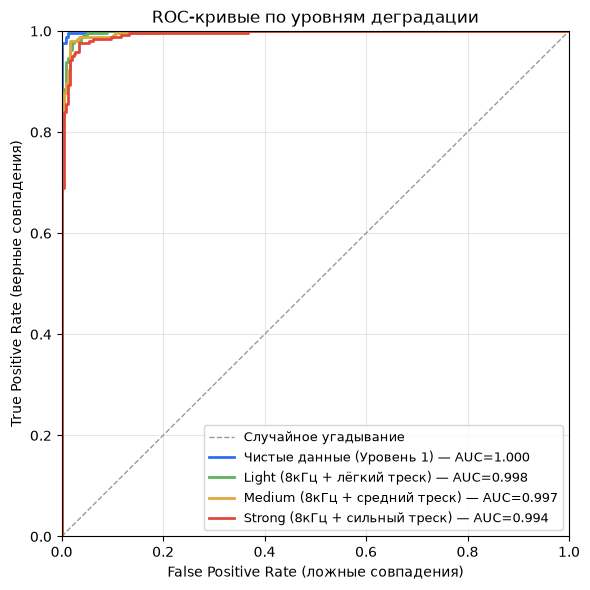

In [11]:
# ROC-кривые всех уровней деградации на одном графике наглядно показывает,
# как форма кривой "проседает" к диагонали (случайному угадыванию) с ростом шума.
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="#9a9a9a", label="Случайное угадывание")

level_colors = {
    "clean": "#2f6fed",
    "light": "#5fb35f",
    "medium": "#e0a83c",
    "strong": "#e0483c",
}
level_labels = {
    "clean": "Чистые данные (Уровень 1)",
    "light": "Light (8кГц + лёгкий треск)",
    "medium": "Medium (8кГц + средний треск)",
    "strong": "Strong (8кГц + сильный треск)",
}

for level, data in degradation_results.items():
    fpr, tpr, _ = roc_curve(data["df"]["true_label"], data["df"]["score"])
    auc = roc_auc_score(data["df"]["true_label"], data["df"]["score"])
    ax.plot(
        fpr, tpr, linewidth=2, color=level_colors[level],
        label=f"{level_labels[level]} — AUC={auc:.3f}",
    )

ax.set_xlabel("False Positive Rate (ложные совпадения)")
ax.set_ylabel("True Positive Rate (верные совпадения)")
ax.set_title("ROC-кривые по уровням деградации")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

### Кривая деградации качества

Итоговый график: как EER (доля ошибок) и accuracy меняются с ростом интенсивности синтетического
треска от чистых данных до `strong`. Это отвечает на вопрос, деградирует ли модель
плавно/линейно или обрушивается резко после определённого порога шума.

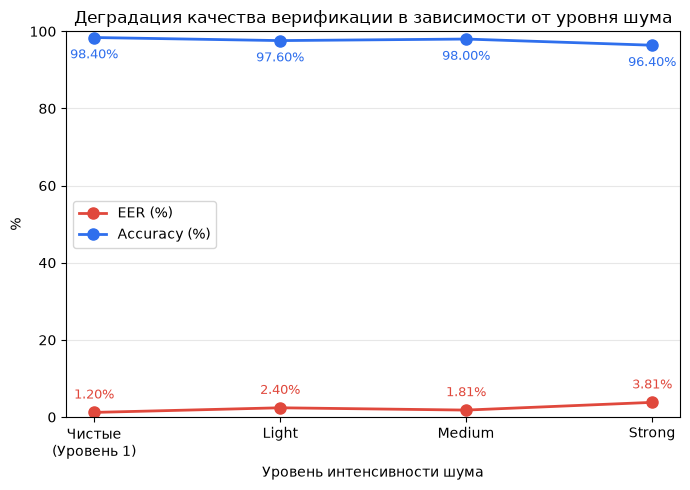

Абсолютный прирост EER относительно чистых данных:
   light: +1.20 п.п.
  medium: +0.61 п.п.
  strong: +2.61 п.п.


In [12]:
levels_order = ["clean", "light", "medium", "strong"]  # по возрастанию интенсивности шума
level_display = ["Чистые\n(Уровень 1)", "Light", "Medium", "Strong"]

eer_curve = [degradation_results[lv]["eer"] * 100 for lv in levels_order]  # в процентах
acc_curve = [degradation_results[lv]["accuracy"] * 100 for lv in levels_order]  # в процентах
x = np.arange(len(levels_order))

fig, ax = plt.subplots(figsize=(7, 5))

# обе кривые в одних единицах (%), поэтому делят одну общую ось Y, не dual-axis
ax.plot(x, eer_curve, marker="o", linewidth=2, markersize=8, color="#e0483c", label="EER (%)")
ax.plot(x, acc_curve, marker="o", linewidth=2, markersize=8, color="#2f6fed", label="Accuracy (%)")

# подписываем значения прямо на точках, удобно читать без наведения курсора
for xi, yi in zip(x, eer_curve):
    ax.annotate(f"{yi:.2f}%", (xi, yi), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color="#e0483c")
for xi, yi in zip(x, acc_curve):
    ax.annotate(f"{yi:.2f}%", (xi, yi), textcoords="offset points", xytext=(0, -15),
                ha="center", fontsize=9, color="#2f6fed")

ax.set_xticks(x)
ax.set_xticklabels(level_display)
ax.set_xlabel("Уровень интенсивности шума")
ax.set_ylabel("%")
ax.set_title("Деградация качества верификации в зависимости от уровня шума")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.legend(loc="center left")
fig.tight_layout()
plt.show()

print("Абсолютный прирост EER относительно чистых данных:")
for lv in levels_order[1:]:
    delta = (degradation_results[lv]["eer"] - degradation_results["clean"]["eer"]) * 100
    print(f"  {lv:>6}: +{delta:.2f} п.п.")

## Этап 3: Калибровка финального threshold

Согласно методологии, threshold нельзя калибровать на одном уровне
шума, иначе порог переобучится под конкретный сценарий (например, только под сильный треск) и
будет неоптимален для остальных условий, с которыми модель встретится на инференсе. Правильный
подход - **смешанный пул**: калибровать порог на объединённом наборе, отражающем весь диапазон
ожидаемых условий, а не один сценарий.

Берём равномерную смесь, по 250 пар на каждый уровень (чистые / light / medium / strong,
всего 1000 пар), считаем один общий EER на объединённом **scores / y_true**, точка EER на этом
пуле и есть калибруемый threshold.

Выборка независима от использованной в этапе 1/2 (другой **random_state=123**), чтобы порог не
калибровался на тех же данных, на которых уже смотрели диагностику деградации.

In [13]:
THRESHOLD_POOL_SIZE_PER_LEVEL = 250

# Независимая выборка от Уровня 1/2 выше (другой random_state) — 4*250=1000 пар,
# делим поровну на 4 непересекающихся чанка, каждому назначаем свой уровень шума.
# .iloc-срезы (а не np.array_split) — чтобы чанки остались DataFrame, а не превратились
# в numpy-массивы без метода itertuples().
threshold_pairs_pool = pairs.sample(THRESHOLD_POOL_SIZE_PER_LEVEL * 4, random_state=123)
chunk_size = THRESHOLD_POOL_SIZE_PER_LEVEL
clean_chunk = threshold_pairs_pool.iloc[0 * chunk_size : 1 * chunk_size]
light_chunk = threshold_pairs_pool.iloc[1 * chunk_size : 2 * chunk_size]
medium_chunk = threshold_pairs_pool.iloc[2 * chunk_size : 3 * chunk_size]
strong_chunk = threshold_pairs_pool.iloc[3 * chunk_size : 4 * chunk_size]

pool_dfs = []

# Чистый чанк — оригинальные 16кГц файлы, без деградации (n=None -> берётся весь df целиком).
clean_res = run_verification(clean_chunk)
pool_dfs.append(clean_res)

# Три деградированных чанка — тот же пайплайн, что и в Уровне 2.
for chunk, intensity in [(light_chunk, "light"), (medium_chunk, "medium"), (strong_chunk, "strong")]:
    degraded_chunk = build_degraded_pairs(chunk, intensity=intensity, downsample_sr=DOWNSAMPLE_SR)
    res = run_verification_on_columns(degraded_chunk, "path1_degraded", "path2_degraded")
    pool_dfs.append(res)

# Объединяем все 4 группы в один пул для единого расчёта EER/threshold.
pooled_results = pd.concat(pool_dfs, ignore_index=True)
print(
    f"Итоговый смешанный пул: {len(pooled_results)} пар "
    f"({THRESHOLD_POOL_SIZE_PER_LEVEL} clean + {THRESHOLD_POOL_SIZE_PER_LEVEL} light + "
    f"{THRESHOLD_POOL_SIZE_PER_LEVEL} medium + {THRESHOLD_POOL_SIZE_PER_LEVEL} strong)"
)

final_eer, final_threshold = compute_eer(pooled_results["true_label"], pooled_results["score"])
final_accuracy = accuracy_score(
    pooled_results["true_label"],
    (pooled_results["score"] > final_threshold).astype(int),
)

print(f"\n>>> Итоговый калиброванный threshold: {final_threshold:.4f}")
print(f"EER на смешанном пуле: {final_eer:.4%}")
print(f"Accuracy при этом threshold: {final_accuracy:.4f}")
print(f"\nДля сравнения: threshold в app.py сейчас = 0.25")

Верификация пар:   0%|          | 0/250 [00:00<?, ?it/s]

Деградация аудио (light):   0%|          | 0/476 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/250 [00:00<?, ?it/s]

Деградация аудио (medium):   0%|          | 0/477 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/250 [00:00<?, ?it/s]

Деградация аудио (strong):   0%|          | 0/475 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/250 [00:00<?, ?it/s]

Итоговый смешанный пул: 1000 пар (250 clean + 250 light + 250 medium + 250 strong)

>>> Итоговый калиброванный threshold: 0.3088
EER на смешанном пуле: 2.4990%
Accuracy при этом threshold: 0.9760

Для сравнения: threshold в app.py сейчас = 0.25


### Калибровка scale

Согласно методологии, **scale не влияет на качество классификации**.
EER/AUC считаются по сырым score до применения sigmoid, а scale лишь определяет, насколько резко
**confidence = sigmoid((score - threshold) * scale)** переходит от 0 к 1 вокруг threshold. Это вопрос
интерпретируемости/калибровки вероятности, а не точности, и подбирается отдельно от threshold.

Подбираем scale через **логистическую регрессию** на том же смешанном пуле (250×4 пар, что и для
threshold в этапе 3): обучаем LogisticRegression предсказывать true_label по одному признаку
score. Модель ищет P(SAME) = sigmoid(a * score + b), что эквивалентно нашей формуле
sigmoid((score - threshold) * scale) при scale = a и threshold = -b / a. Так scale получается
не "на глаз", а как параметр, дающий статистически откалиброванную вероятность (если confidence=0.7,
модель права в ~70% таких случаев), а не просто "красиво выглядящее" число.

In [14]:
from sklearn.linear_model import LogisticRegression

# Тот же смешанный пул, что и для threshold — независимая от диагностики выборка.
X_pool = pooled_results["score"].to_numpy().reshape(-1, 1)
y_pool = pooled_results["true_label"].to_numpy()

lr = LogisticRegression()
lr.fit(X_pool, y_pool)

fitted_scale = float(lr.coef_[0, 0])
fitted_intercept = float(lr.intercept_[0])
implied_threshold = -fitted_intercept / fitted_scale  # граница принятия решения, для сверки с final_threshold

print(f"Откалиброванный scale (через LogisticRegression): {fitted_scale:.4f}")
print(f"Порог, подразумеваемый этой моделью: {implied_threshold:.4f}")
print(f"Для сравнения threshold из этапа 3 (EER): {final_threshold:.4f}")
print(f"\nТекущий scale в app.py: 8.0")

# Sanity check калибровки: Brier score (среднеквадратичная ошибка вероятности) —
# чем ниже, тем лучше confidence соответствует реальной частоте правильных ответов.
from sklearn.metrics import brier_score_loss

proba_fitted = lr.predict_proba(X_pool)[:, 1]
proba_old_scale = 1 / (1 + np.exp(-(pooled_results["score"] - final_threshold) * 8.0))

print(f"\nBrier score (текущий scale=8.0):         {brier_score_loss(y_pool, proba_old_scale):.4f}")
print(f"Brier score (откалиброванный scale={fitted_scale:.2f}): {brier_score_loss(y_pool, proba_fitted):.4f}")
print("(меньше — лучше; откалиброванный scale даёт статистически более честный confidence)")

Откалиброванный scale (через LogisticRegression): 11.4114
Порог, подразумеваемый этой моделью: 0.3242
Для сравнения threshold из этапа 3 (EER): 0.3088

Текущий scale в app.py: 8.0

Brier score (текущий scale=8.0):         0.0404
Brier score (откалиброванный scale=11.41): 0.0282
(меньше — лучше; откалиброванный scale даёт статистически более честный confidence)


## Уровень 4: Кросс-датасетная проверка обобщаемости (CN-Celeb)

Отвечает на вопрос: **не переобучился ли threshold под наш собственный синтетический шум?**
VoxCeleb1 (этапы 1-3) — студийные записи, а наш треск синтетический. CN-Celeb, наоборот,
"полевой" датасет: записан в реальных шумных условиях (интервью, шоу, речь на публике и т.д.),
без искусственной деградации с нашей стороны. Если threshold, откалиброванный на VoxCeleb + наш
синтетический шум, всё ещё разумно работает на CN-Celeb — это сильный аргумент, что порог
устойчив в целом, а не подогнан под конкретный вид шума.

Используем официальный evaluation-протокол `CN-Celeb_flac/eval/`:
- `lists/trials.lst` — 3 484 292 пары (`enroll_id test_file label`),
  196 дикторов × 17 777 тестовых файлов. Сильно несбалансирован (~0.5% положительных).
- Пути в списках указаны с расширением `.wav`, реальные файлы — `.flac` (нужно заменить
  расширение при построении полного пути).

Берём **стратифицированную** подвыборку — по 250 положительных и 250 отрицательных пар (всего
500), чтобы получить сбалансированный набор для честной оценки EER.

In [15]:
CNCELEB_ROOT = "CN-Celeb_flac/eval"
TRIALS_PATH = os.path.join(CNCELEB_ROOT, "lists/trials.lst")
CNCELEB_SAMPLE_PER_CLASS = 250

def cnceleb_full_path(rel_path):
    """Строит полный путь к файлу CN-Celeb. Списки (trials.lst/enroll.lst) ссылаются на
    расширение .wav, но реальные файлы на диске — .flac (CN-Celeb_flac) — заменяем."""
    if rel_path.endswith(".wav"):
        rel_path = rel_path[: -len(".wav")] + ".flac"
    return os.path.join(CNCELEB_ROOT, rel_path)

# trials.lst большой (3.48М строк) — читаем целиком, это ~180МБ текста, но всего 3 колонки.
trials = pd.read_csv(TRIALS_PATH, sep=" ", header=None, names=["enroll_id", "test_file", "label"])
print(f"Всего пар в trials.lst: {len(trials)}")
print(trials["label"].value_counts().rename({1: "SAME", 0: "DIFFERENT"}))

# Стратифицированная подвыборка: по 250 на класс, т.к. простой random.sample почти
# не захватил бы label=1 (их всего ~0.5% от датасета).
pos_sample = trials[trials["label"] == 1].sample(CNCELEB_SAMPLE_PER_CLASS, random_state=42)
neg_sample = trials[trials["label"] == 0].sample(CNCELEB_SAMPLE_PER_CLASS, random_state=42)
cnceleb_sample = pd.concat([pos_sample, neg_sample], ignore_index=True)

# enroll_id уже содержит суффикс "-enroll" (например "id00800-enroll") -> файл enroll/<enroll_id>.wav.
# test_file уже полный относительный путь (например "test/id00800-singing-01-001.wav").
cnceleb_sample["enroll_path"] = cnceleb_sample["enroll_id"].apply(
    lambda x: cnceleb_full_path(f"enroll/{x}.wav")
)
cnceleb_sample["test_path"] = cnceleb_sample["test_file"].apply(cnceleb_full_path)

cnceleb_sample.head()

Всего пар в trials.lst: 3484292
label
DIFFERENT    3466537
SAME           17755
Name: count, dtype: int64


,enroll_id,test_file,label,enroll_path,test_path
0,id00859-enroll,test/id00859-live_broadcast-03-128.wav,1,CN-Celeb_flac/eval/enroll/id00859-enroll.flac,CN-Celeb_flac/eval/test/id00859-live_broadcast...
1,id00917-enroll,test/id00917-interview-02-023.wav,1,CN-Celeb_flac/eval/enroll/id00917-enroll.flac,CN-Celeb_flac/eval/test/id00917-interview-02-0...
2,id00979-enroll,test/id00979-interview-02-072.wav,1,CN-Celeb_flac/eval/enroll/id00979-enroll.flac,CN-Celeb_flac/eval/test/id00979-interview-02-0...
3,id00850-enroll,test/id00850-singing-06-006.wav,1,CN-Celeb_flac/eval/enroll/id00850-enroll.flac,CN-Celeb_flac/eval/test/id00850-singing-06-006...
4,id00810-enroll,test/id00810-entertainment-03-017.wav,1,CN-Celeb_flac/eval/enroll/id00810-enroll.flac,CN-Celeb_flac/eval/test/id00810-entertainment-...


In [16]:
cnceleb_results = run_verification_on_columns(cnceleb_sample, "enroll_path", "test_path")

cnceleb_eer, cnceleb_eer_threshold = compute_eer(
    cnceleb_results["true_label"], cnceleb_results["score"]
)
cnceleb_auc = roc_auc_score(cnceleb_results["true_label"], cnceleb_results["score"])

print(f"Размер выборки: {len(cnceleb_results)} пар ({CNCELEB_SAMPLE_PER_CLASS} SAME + {CNCELEB_SAMPLE_PER_CLASS} DIFFERENT)")
print(f"AUC: {cnceleb_auc:.4f}")
print(f"EER (своя точка на CN-Celeb): {cnceleb_eer:.4%} при threshold={cnceleb_eer_threshold:.4f}")

# Главный вопрос уровня: как ведёт себя threshold, откалиброванный на VoxCeleb (Уровень 3),
# если применить его "как есть" к незнакомому (out-of-distribution) датасету?
# accuracy_at_threshold определена в разделе "Метрики качества" выше.
print("\nОбобщаемость калиброванных threshold на CN-Celeb (без переобучения под него):")
for label, th in [
    ("app.py по умолчанию (0.25)", 0.25),
    ("откалиброванный на VoxCeleb, Уровень 3", final_threshold),
]:
    acc = accuracy_at_threshold(cnceleb_results["true_label"], cnceleb_results["score"], th)
    print(f"  {label:>42}: threshold={th:.4f} -> accuracy={acc:.4f}")

print(
    f"\nДля сравнения EER на VoxCeleb (Уровень 1, чистые данные): {baseline_eer:.4%}"
    f"\nEER на CN-Celeb (out-of-distribution):                    {cnceleb_eer:.4%}"
)

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

Размер выборки: 500 пар (250 SAME + 250 DIFFERENT)
AUC: 0.9014
EER (своя точка на CN-Celeb): 15.2000% при threshold=0.2802

Обобщаемость калиброванных threshold на CN-Celeb (без переобучения под него):
                  app.py по умолчанию (0.25): threshold=0.2500 -> accuracy=0.8300
      откалиброванный на VoxCeleb, Уровень 3: threshold=0.3088 -> accuracy=0.8460

Для сравнения EER на VoxCeleb (Уровень 1, чистые данные): 1.2007%
EER на CN-Celeb (out-of-distribution):                    15.2000%


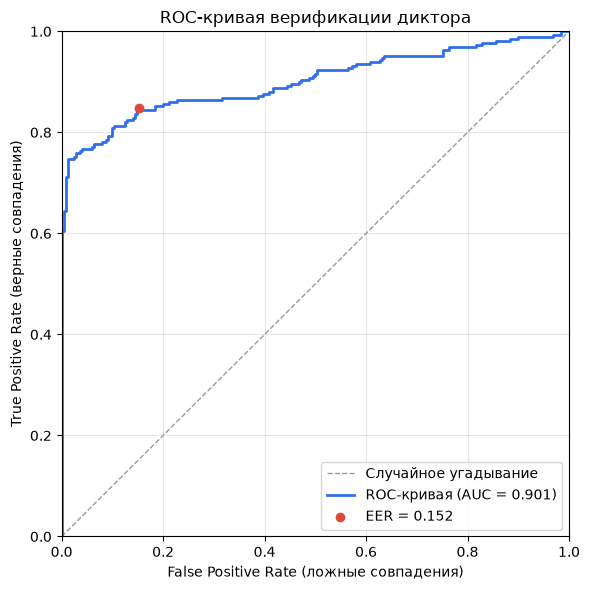

In [17]:
# ROC-кривая на CN-Celeb. Визуальная проверка, что разделение классов не разваливается
# на незнакомом (out-of-distribution) датасете.
_ = plot_roc_curve(cnceleb_results["true_label"], cnceleb_results["score"])

#### Деградация качества на CN-Celeb

Применяем тот же пайплайн деградации, что и в Этапе 2 (downsample до 8кГц + синтетический треск
light/medium/strong), но теперь поверх пар CN-Celeb (`cnceleb_sample`), а не VoxCeleb. CN-Celeb уже
содержит естественный "полевой" шум — интересно, насколько сильно дополнительная синтетическая
деградация ухудшает результат поверх уже присутствующего реального шума, и ведёт ли себя тренд
так же, как на чистом VoxCeleb.

In [18]:
CNCELEB_DEGRADED_ROOT = os.path.join(DEGRADED_ROOT, "cnceleb")

cnceleb_degradation_results = {
    "clean": {
        "df": cnceleb_results,
        "eer": cnceleb_eer,
        "accuracy": accuracy_score(cnceleb_results["true_label"], cnceleb_results["predicted_label"]),
    }
}

for intensity in CRACKLE_PRESETS:  # light -> medium -> strong
    degraded = build_degraded_pairs_from_full_paths(
        cnceleb_sample, "enroll_path", "test_path",
        intensity=intensity, downsample_sr=DOWNSAMPLE_SR,
        cache_root=CNCELEB_DEGRADED_ROOT, loader=load_and_preprocess,
    )
    res = run_verification_on_columns(degraded, "path1_degraded", "path2_degraded")
    eer, threshold = compute_eer(res["true_label"], res["score"])
    acc = accuracy_score(res["true_label"], res["predicted_label"])
    cnceleb_degradation_results[intensity] = {"df": res, "eer": eer, "threshold": threshold, "accuracy": acc}
    print(f"[{intensity:>6}] EER: {eer:.4%} | Accuracy: {acc:.4f} | threshold={threshold:.4f}")

print(f"\n[{'clean':>6}] EER: {cnceleb_eer:.4%} | Accuracy: {cnceleb_degradation_results['clean']['accuracy']:.4f} (без доп. деградации)")

Деградация аудио (light):   0%|          | 0/674 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[ light] EER: 18.8000% | Accuracy: 0.8020 | threshold=0.3691


Деградация аудио (medium):   0%|          | 0/674 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[medium] EER: 18.2000% | Accuracy: 0.7820 | threshold=0.3707


Деградация аудио (strong):   0%|          | 0/674 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[strong] EER: 20.2000% | Accuracy: 0.8020 | threshold=0.3253

[ clean] EER: 15.2000% | Accuracy: 0.8460 (без доп. деградации)


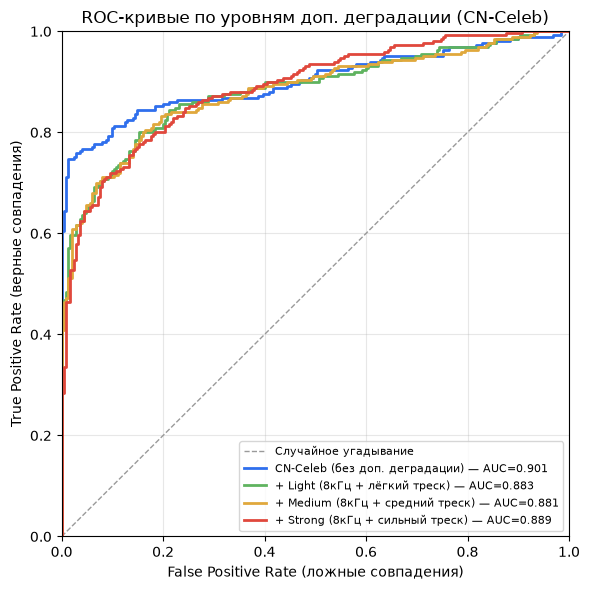

In [19]:
# ROC-кривые по уровням деградации на CN-Celeb — на одном графике.
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="#9a9a9a", label="Случайное угадывание")

level_colors = {"clean": "#2f6fed", "light": "#5fb35f", "medium": "#e0a83c", "strong": "#e0483c"}
level_labels = {
    "clean": "CN-Celeb (без доп. деградации)",
    "light": "+ Light (8кГц + лёгкий треск)",
    "medium": "+ Medium (8кГц + средний треск)",
    "strong": "+ Strong (8кГц + сильный треск)",
}

for level, data in cnceleb_degradation_results.items():
    fpr, tpr, _ = roc_curve(data["df"]["true_label"], data["df"]["score"])
    auc = roc_auc_score(data["df"]["true_label"], data["df"]["score"])
    ax.plot(fpr, tpr, linewidth=2, color=level_colors[level], label=f"{level_labels[level]} — AUC={auc:.3f}")

ax.set_xlabel("False Positive Rate (ложные совпадения)")
ax.set_ylabel("True Positive Rate (верные совпадения)")
ax.set_title("ROC-кривые по уровням доп. деградации (CN-Celeb)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

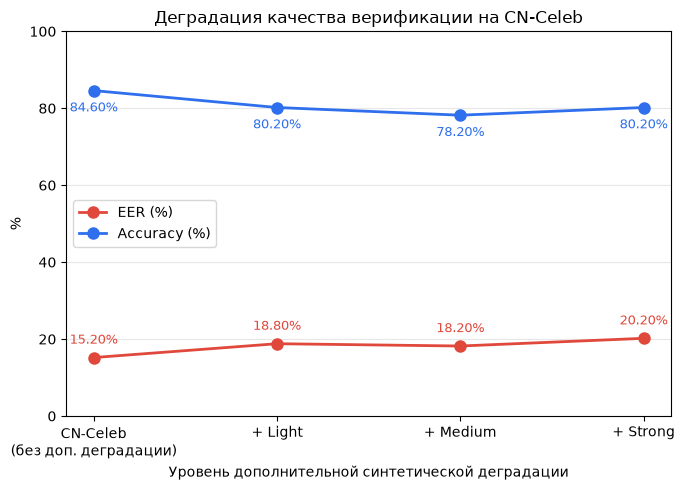

In [20]:
# Кривая деградации (EER/Accuracy vs уровень доп. шума) на CN-Celeb.
levels_order_cnc = ["clean", "light", "medium", "strong"]
level_display_cnc = ["CN-Celeb\n(без доп. деградации)", "+ Light", "+ Medium", "+ Strong"]

eer_curve_cnc = [cnceleb_degradation_results[lv]["eer"] * 100 for lv in levels_order_cnc]
acc_curve_cnc = [cnceleb_degradation_results[lv]["accuracy"] * 100 for lv in levels_order_cnc]
x = np.arange(len(levels_order_cnc))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, eer_curve_cnc, marker="o", linewidth=2, markersize=8, color="#e0483c", label="EER (%)")
ax.plot(x, acc_curve_cnc, marker="o", linewidth=2, markersize=8, color="#2f6fed", label="Accuracy (%)")

for xi, yi in zip(x, eer_curve_cnc):
    ax.annotate(f"{yi:.2f}%", (xi, yi), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="#e0483c")
for xi, yi in zip(x, acc_curve_cnc):
    ax.annotate(f"{yi:.2f}%", (xi, yi), textcoords="offset points", xytext=(0, -15), ha="center", fontsize=9, color="#2f6fed")

ax.set_xticks(x)
ax.set_xticklabels(level_display_cnc)
ax.set_xlabel("Уровень дополнительной синтетической деградации")
ax.set_ylabel("%")
ax.set_title("Деградация качества верификации на CN-Celeb")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.legend(loc="center left")
fig.tight_layout()
plt.show()

## Этап 5: Робастность на русскоязычном датасете (Common Voice ru)

Ещё одна проверка обобщаемости — на этот раз на **русской речи**. Используем корпус
Mozilla Common Voice 26.0 (`ru`), лежащий в `cv-corpus-26.0-2026-06-12/ru/`.

Формат — стандартный Common Voice: `validated.tsv` содержит колонки `client_id` (id диктора)
и `path` (имя `.mp3`-файла в `clips/`). Готового списка верификационных пар (как `veri_test2.txt`
у VoxCeleb или `trials.lst` у CN-Celeb) в датасете нет — Common Voice размечен для ASR, а не для
speaker verification, поэтому пары строим сами, по той же схеме, что и раньше:
- **SAME**: два разных клипа одного диктора (берём дикторов с ≥2 записями).
- **DIFFERENT**: по одному клипу от двух разных случайных дикторов.

Технический нюанс: файлы — `.mp3`, а `soundfile`/`libsndfile` в этом окружении не умеет их
декодировать (`load_and_preprocess` из `app.py` тут не подходит). Декодируем через `av` (PyAV,
собственный статически собранный ffmpeg) — ставится через `pip install av`, добавлено в
`requirements.txt`.

Как и в Этапе 4, дополнительно проверяем **устойчивость откалиброванного threshold**: сравниваем
accuracy при `threshold=0.3088` (Этап 3) и при дефолтном `0.25`.

In [21]:
import av
from app import classifier

CV_ROOT = "cv-corpus-26.0-2026-06-12/ru"
CV_CLIPS_DIR = os.path.join(CV_ROOT, "clips")
CV_TSV_PATH = os.path.join(CV_ROOT, "validated.tsv")
CV_SAMPLE_PER_CLASS = 250


def load_and_preprocess_cv(path, target_sr=16000):
    """Аналог load_and_preprocess() из app.py, но для .mp3 (Common Voice). soundfile/libsndfile
    в этом окружении не умеет декодировать mp3 (falls back to 'System error'), поэтому используем
    PyAV — декодирует и сразу ресемплирует до моно/target_sr, минуя необходимость в ffmpeg CLI."""
    container = av.open(path)
    stream = container.streams.audio[0]
    resampler = av.AudioResampler(format="fltp", layout="mono", rate=target_sr)
    frames = []
    for packet in container.demux(stream):
        for frame in packet.decode():
            for rframe in resampler.resample(frame):
                frames.append(rframe.to_ndarray())
    container.close()
    if not frames:
        return torch.zeros((1, 0))
    wav = np.concatenate(frames, axis=1)  # (1, samples), моно float32
    return torch.from_numpy(wav)


def get_embedding_cv(path):
    """Как get_embedding() из app.py, но через load_and_preprocess_cv (модель та же — переиспользуем
    уже загруженный app.classifier, а не грузим веса второй раз)."""
    wav = load_and_preprocess_cv(path)
    emb = classifier.encode_batch(wav)
    return emb.squeeze()


def verify_cv(path1, path2, threshold=0.3088, scale=11.41):
    """Как verify() из app.py, но для mp3-файлов Common Voice (через get_embedding_cv)."""
    e1, e2 = get_embedding_cv(path1), get_embedding_cv(path2)
    score = torch.nn.functional.cosine_similarity(e1, e2, dim=0).item()
    confidence = torch.sigmoid(torch.tensor((score - threshold) * scale)).item()
    label = "SAME" if score > threshold else "DIFFERENT"
    return label, confidence, score


# Читаем только нужные колонки — файл большой (176К строк).
cv_meta = pd.read_csv(CV_TSV_PATH, sep="\t", usecols=["client_id", "path"])
print(f"Всего записей: {len(cv_meta)}, уникальных дикторов: {cv_meta['client_id'].nunique()}")

speaker_to_clips = cv_meta.groupby("client_id")["path"].apply(list).to_dict()
eligible_speakers = [spk for spk, clips in speaker_to_clips.items() if len(clips) >= 2]
all_speakers = list(speaker_to_clips.keys())
print(f"Дикторов с >=2 клипами (годятся для SAME-пар): {len(eligible_speakers)}")

rng = np.random.default_rng(42)

# SAME: для каждого из 250 случайных дикторов берём 2 случайных его клипа.
same_speakers = rng.choice(eligible_speakers, size=CV_SAMPLE_PER_CLASS, replace=False)
same_pairs = []
for spk in same_speakers:
    p1, p2 = rng.choice(speaker_to_clips[spk], size=2, replace=False)
    same_pairs.append({"path1": p1, "path2": p2, "label": 1, "user1_id": spk, "user2_id": spk})

# DIFFERENT: 250 раз берём двух разных случайных дикторов, по одному клипу у каждого.
diff_pairs = []
for _ in range(CV_SAMPLE_PER_CLASS):
    spk1, spk2 = rng.choice(all_speakers, size=2, replace=False)
    p1 = rng.choice(speaker_to_clips[spk1])
    p2 = rng.choice(speaker_to_clips[spk2])
    diff_pairs.append({"path1": p1, "path2": p2, "label": 0, "user1_id": spk1, "user2_id": spk2})

cv_pairs = pd.DataFrame(same_pairs + diff_pairs)
cv_pairs["path1_full"] = cv_pairs["path1"].apply(lambda p: os.path.join(CV_CLIPS_DIR, p))
cv_pairs["path2_full"] = cv_pairs["path2"].apply(lambda p: os.path.join(CV_CLIPS_DIR, p))

print(f"\nСформировано пар: {len(cv_pairs)} ({CV_SAMPLE_PER_CLASS} SAME + {CV_SAMPLE_PER_CLASS} DIFFERENT)")
cv_pairs.head()

Всего записей: 176302, уникальных дикторов: 3286
Дикторов с >=2 клипами (годятся для SAME-пар): 3061

Сформировано пар: 500 (250 SAME + 250 DIFFERENT)


,path1,path2,label,user1_id,user2_id,path1_full,path2_full
0,common_voice_ru_38207672.mp3,common_voice_ru_38207671.mp3,1,f548b38820693eff1227bb2c70cdbd8536f8d635648937...,f548b38820693eff1227bb2c70cdbd8536f8d635648937...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...
1,common_voice_ru_22727659.mp3,common_voice_ru_22727657.mp3,1,984aa6fd73e81d038797771d2dd1831e7070fe44664a54...,984aa6fd73e81d038797771d2dd1831e7070fe44664a54...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...
2,common_voice_ru_42834771.mp3,common_voice_ru_42834800.mp3,1,6537f1d0444d208521233e156fc9c08513d1186f70748e...,6537f1d0444d208521233e156fc9c08513d1186f70748e...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...
3,common_voice_ru_37237726.mp3,common_voice_ru_37237723.mp3,1,6a24ca764e9ae903fa895e3621ac017b3549164f544f4d...,6a24ca764e9ae903fa895e3621ac017b3549164f544f4d...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...
4,common_voice_ru_25023257.mp3,common_voice_ru_25023221.mp3,1,06d4c8ea454687bdedd25306e09983ce8a557b8858962f...,06d4c8ea454687bdedd25306e09983ce8a557b8858962f...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...,cv-corpus-26.0-2026-06-12/ru/clips/common_voic...


In [22]:
def run_verification_cv(df, path1_col, path2_col):
    """Как run_verification_on_columns(), но зовёт verify_cv() (mp3-декодер через PyAV)."""
    results = []
    skipped = 0
    pbar = tqdm(df.itertuples(index=False), total=len(df), desc="Верификация пар (Common Voice ru)")
    for row in pbar:
        p1, p2 = getattr(row, path1_col), getattr(row, path2_col)
        if not (os.path.exists(p1) and os.path.exists(p2)):
            skipped += 1
            pbar.set_postfix(skipped=skipped)
            continue
        label, confidence, score = verify_cv(p1, p2)
        results.append({
            "true_label": row.label,
            "predicted_label": 1 if label == "SAME" else 0,
            "score": score,
            "confidence": confidence,
        })
        pbar.set_postfix(skipped=skipped)
    return pd.DataFrame(results)


cv_results = run_verification_cv(cv_pairs, "path1_full", "path2_full")

cv_eer, cv_eer_threshold = compute_eer(cv_results["true_label"], cv_results["score"])
cv_auc = roc_auc_score(cv_results["true_label"], cv_results["score"])

print(f"Размер выборки: {len(cv_results)} пар ({CV_SAMPLE_PER_CLASS} SAME + {CV_SAMPLE_PER_CLASS} DIFFERENT)")
print(f"AUC: {cv_auc:.4f}")
print(f"EER (своя точка на Common Voice ru): {cv_eer:.4%} при threshold={cv_eer_threshold:.4f}")

print("\nОбобщаемость калиброванных threshold на Common Voice ru (без переобучения под него):")
for label_, th in [
    ("app.py по умолчанию (0.25)", 0.25),
    ("откалиброванный на VoxCeleb, Этап 3", final_threshold),
]:
    acc = accuracy_at_threshold(cv_results["true_label"], cv_results["score"], th)
    print(f"  {label_:>42}: threshold={th:.4f} -> accuracy={acc:.4f}")

print(
    f"\nДля сравнения EER на VoxCeleb (Этап 1, чистые данные): {baseline_eer:.4%}"
    f"\nEER на CN-Celeb (Этап 4, out-of-distribution):         {cnceleb_eer:.4%}"
    f"\nEER на Common Voice ru (out-of-distribution):          {cv_eer:.4%}"
)

Верификация пар (Common Voice ru):   0%|          | 0/500 [00:00<?, ?it/s]

Размер выборки: 500 пар (250 SAME + 250 DIFFERENT)
AUC: 0.9798
EER (своя точка на Common Voice ru): 7.0000% при threshold=0.3304

Обобщаемость калиброванных threshold на Common Voice ru (без переобучения под него):
                  app.py по умолчанию (0.25): threshold=0.2500 -> accuracy=0.9120
         откалиброванный на VoxCeleb, Этап 3: threshold=0.3088 -> accuracy=0.9320

Для сравнения EER на VoxCeleb (Этап 1, чистые данные): 1.2007%
EER на CN-Celeb (Этап 4, out-of-distribution):         15.2000%
EER на Common Voice ru (out-of-distribution):          7.0000%


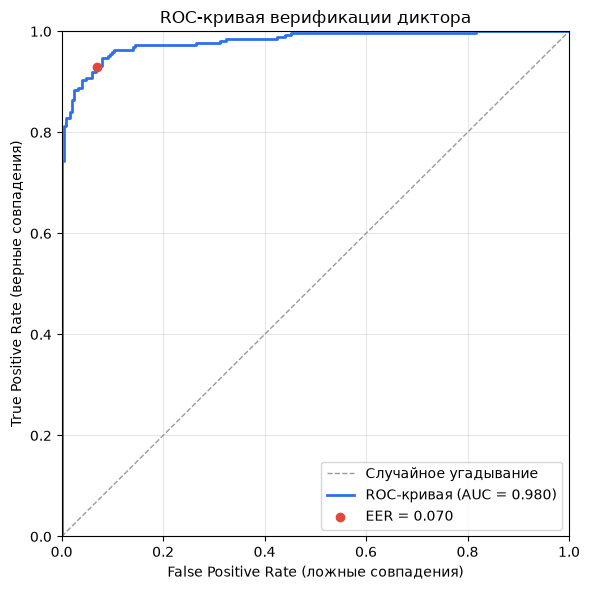

In [23]:
# ROC-кривая на Common Voice ru — визуальная проверка разделимости классов на русской речи.
_ = plot_roc_curve(cv_results["true_label"], cv_results["score"])

#### Деградация качества на Common Voice ru

Тот же пайплайн деградации (downsample до 8кГц + синтетический треск light/medium/strong), но
поверх пар Common Voice ru (`cv_pairs`). Источник — `.mp3`, поэтому для чтения исходников
используется `load_and_preprocess_cv` (PyAV); после наложения треска результат сохраняется как
обычный `.wav`, дальше верификация идёт стандартным `run_verification_on_columns`/`app.verify()`,
как и для остальных датасетов.

In [24]:
CV_DEGRADED_ROOT = os.path.join(DEGRADED_ROOT, "cv_ru")

cv_degradation_results = {
    "clean": {
        "df": cv_results,
        "eer": cv_eer,
        "accuracy": accuracy_score(cv_results["true_label"], cv_results["predicted_label"]),
    }
}

for intensity in CRACKLE_PRESETS:  # light -> medium -> strong
    degraded = build_degraded_pairs_from_full_paths(
        cv_pairs, "path1_full", "path2_full",
        intensity=intensity, downsample_sr=DOWNSAMPLE_SR,
        cache_root=CV_DEGRADED_ROOT, loader=load_and_preprocess_cv,
    )
    res = run_verification_on_columns(degraded, "path1_degraded", "path2_degraded")
    eer, threshold = compute_eer(res["true_label"], res["score"])
    acc = accuracy_score(res["true_label"], res["predicted_label"])
    cv_degradation_results[intensity] = {"df": res, "eer": eer, "threshold": threshold, "accuracy": acc}
    print(f"[{intensity:>6}] EER: {eer:.4%} | Accuracy: {acc:.4f} | threshold={threshold:.4f}")

print(f"\n[{'clean':>6}] EER: {cv_eer:.4%} | Accuracy: {cv_degradation_results['clean']['accuracy']:.4f} (без доп. деградации)")

Деградация аудио (light):   0%|          | 0/977 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[ light] EER: 9.4000% | Accuracy: 0.8700 | threshold=0.4158


Деградация аудио (medium):   0%|          | 0/977 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[medium] EER: 6.6000% | Accuracy: 0.8700 | threshold=0.4018


Деградация аудио (strong):   0%|          | 0/977 [00:00<?, ?it/s]

Верификация пар:   0%|          | 0/500 [00:00<?, ?it/s]

[strong] EER: 7.8000% | Accuracy: 0.9080 | threshold=0.3591

[ clean] EER: 7.0000% | Accuracy: 0.9320 (без доп. деградации)


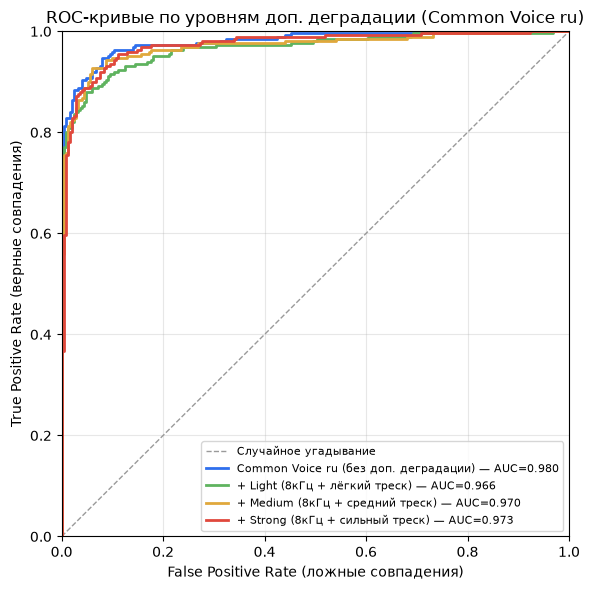

In [25]:
# ROC-кривые по уровням деградации на Common Voice ru — на одном графике.
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="#9a9a9a", label="Случайное угадывание")

level_colors = {"clean": "#2f6fed", "light": "#5fb35f", "medium": "#e0a83c", "strong": "#e0483c"}
level_labels = {
    "clean": "Common Voice ru (без доп. деградации)",
    "light": "+ Light (8кГц + лёгкий треск)",
    "medium": "+ Medium (8кГц + средний треск)",
    "strong": "+ Strong (8кГц + сильный треск)",
}

for level, data in cv_degradation_results.items():
    fpr, tpr, _ = roc_curve(data["df"]["true_label"], data["df"]["score"])
    auc = roc_auc_score(data["df"]["true_label"], data["df"]["score"])
    ax.plot(fpr, tpr, linewidth=2, color=level_colors[level], label=f"{level_labels[level]} — AUC={auc:.3f}")

ax.set_xlabel("False Positive Rate (ложные совпадения)")
ax.set_ylabel("True Positive Rate (верные совпадения)")
ax.set_title("ROC-кривые по уровням доп. деградации (Common Voice ru)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

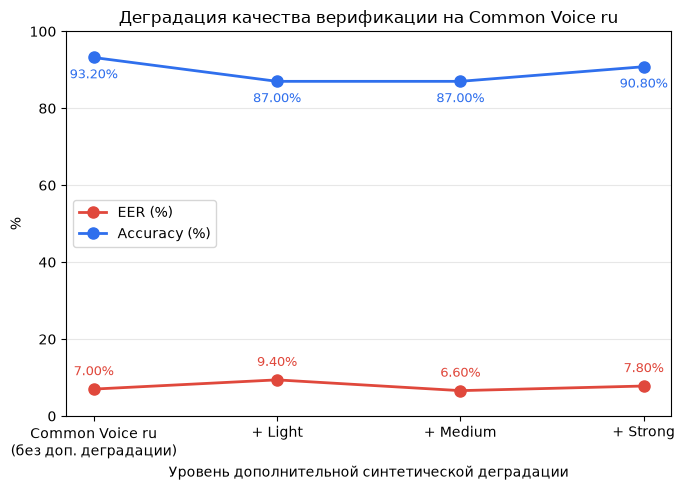

In [26]:
# Кривая деградации (EER/Accuracy vs уровень доп. шума) на Common Voice ru.
levels_order_cv = ["clean", "light", "medium", "strong"]
level_display_cv = ["Common Voice ru\n(без доп. деградации)", "+ Light", "+ Medium", "+ Strong"]

eer_curve_cv = [cv_degradation_results[lv]["eer"] * 100 for lv in levels_order_cv]
acc_curve_cv = [cv_degradation_results[lv]["accuracy"] * 100 for lv in levels_order_cv]
x = np.arange(len(levels_order_cv))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, eer_curve_cv, marker="o", linewidth=2, markersize=8, color="#e0483c", label="EER (%)")
ax.plot(x, acc_curve_cv, marker="o", linewidth=2, markersize=8, color="#2f6fed", label="Accuracy (%)")

for xi, yi in zip(x, eer_curve_cv):
    ax.annotate(f"{yi:.2f}%", (xi, yi), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="#e0483c")
for xi, yi in zip(x, acc_curve_cv):
    ax.annotate(f"{yi:.2f}%", (xi, yi), textcoords="offset points", xytext=(0, -15), ha="center", fontsize=9, color="#2f6fed")

ax.set_xticks(x)
ax.set_xticklabels(level_display_cv)
ax.set_xlabel("Уровень дополнительной синтетической деградации")
ax.set_ylabel("%")
ax.set_title("Деградация качества верификации на Common Voice ru")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.legend(loc="center left")
fig.tight_layout()
plt.show()